## Соревнование "OTTO – Multi-Objective Recommender System"

https://www.kaggle.com/competitions/otto-recommender-system/overview

### Описание соревнования

#### Оценка результатов
Решения оцениваются по метрике **Recall@20** для каждого типа действий, а итоговая оценка представляет собой средневзвешенное значение трех показателей $R$:

$$ score = 0.10 \cdot R_{clicks} + 0.30 \cdot R_{carts} + 0.60 \cdot R_{orders} $$

где $R_{type}$ определяется следующей формулой:

$$ R_{type} = \frac{\sum_{i}^N |\{\text{predicted aids}\}_{i, type} \cap \{\text{ground truth aids}\}_{i, type}|}{\sum_{i}^N \min(20, |\{\text{ground truth aids}\}_{i, type}|)} $$

Разбор переменных:
* $N$ — общее количество сессий в тестовой выборке;
* Предсказания для каждого типа сессии (каждая строка в файле отправки) усекаются после первых 20 значений;
* `aids` — идентификаторы товаров (article ID).

##### Определение целевых переменных
Для каждой сессии в тестовых данных ваша задача — предсказать идентификаторы товаров (`aid`) для каждого типа действия, которые произойдут **после последней временной метки (`ts`)** этой тестовой сессии. Иными словами, тестовые данные содержат сессии, обрезанные по времени, и вы должны предсказать, что произойдет после момента обрезки.

* **Для кликов (clicks)** существует только **одно** истинное значение для каждой сессии — это следующий `aid`, на который кликнет пользователь (однако вы все равно можете предсказывать до 20 значений в качестве кандидатов).
* **Для корзин (carts) и заказов (orders)** истинные значения включают **все** `aid`, которые были добавлены в корзину или заказаны в течение сессии соответственно.


Бейзлайн: https://www.kaggle.com/code/pristukes/otto-getting-started-eda-baseline

In [ ]:
import pandas as pd
from pathlib import Path
import os
import random
import numpy as np
import json
from datetime import timedelta
from collections import Counter
from tqdm.notebook import tqdm
from heapq import nlargest

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
import lightgbm as lgb

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import userdata

os.environ['KAGGLE_USERNAME'] = userdata.get('KAGGLE_USERNAME')
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

In [ ]:
print(os.environ['KAGGLE_USERNAME'])
print(os.environ['KAGGLE_API_TOKEN'][:5])

alexo375
KGAT_


In [ ]:
DATA_PATH = '/content/drive/MyDrive/kaggle/otto'
TRAIN_PATH = f"{DATA_PATH}/train.jsonl"
TEST_PATH = f"{DATA_PATH}/test.jsonl"

if not os.path.exists(f'{DATA_PATH}/otto-recommender-system.zip'):
    !kaggle competitions download -c otto-recommender-system -p {DATA_PATH}

if not os.path.exists(TRAIN_PATH):
    !unzip {DATA_PATH}/otto-recommender-system.zip -d {DATA_PATH}

In [ ]:
SAMPLE_SUB_PATH = Path(f'{DATA_PATH}/sample_submission.csv')
SUB_PATH = Path(f'{DATA_PATH}/submission.csv')

### EDA

In [ ]:
sample_train_df = pd.read_json(TRAIN_PATH, lines=True, nrows=100000)

In [ ]:
sample_train_df.head()

,session,events
0,0,"[{'aid': 1517085, 'ts': 1659304800025, 'type':..."
1,1,"[{'aid': 424964, 'ts': 1659304800025, 'type': ..."
2,2,"[{'aid': 763743, 'ts': 1659304800038, 'type': ..."
3,3,"[{'aid': 1425967, 'ts': 1659304800095, 'type':..."
4,4,"[{'aid': 613619, 'ts': 1659304800119, 'type': ..."


In [ ]:
sample_train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 2 columns):
 #   Column   Non-Null Count   Dtype 
---  ------   --------------   ----- 
 0   session  100000 non-null  int64 
 1   events   100000 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.5+ MB


In [ ]:
sample_train_df.set_index('session', drop=True, inplace=True)

In [ ]:
sample_train_df.head()

,events
session,
0,"[{'aid': 1517085, 'ts': 1659304800025, 'type':..."
1,"[{'aid': 424964, 'ts': 1659304800025, 'type': ..."
2,"[{'aid': 763743, 'ts': 1659304800038, 'type': ..."
3,"[{'aid': 1425967, 'ts': 1659304800095, 'type':..."
4,"[{'aid': 613619, 'ts': 1659304800119, 'type': ..."


In [ ]:
example_session = sample_train_df.iloc[0].item()
print(f'The first session was {len(example_session)} actions long \n')
print(f'The first action in the session: \n {example_session[0]} \n')
example_session[:10]

The first session was 276 actions long 

The first action in the session: 
 {'aid': 1517085, 'ts': 1659304800025, 'type': 'clicks'} 



[{'aid': 1517085, 'ts': 1659304800025, 'type': 'clicks'},
 {'aid': 1563459, 'ts': 1659304904511, 'type': 'clicks'},
 {'aid': 1309446, 'ts': 1659367439426, 'type': 'clicks'},
 {'aid': 16246, 'ts': 1659367719997, 'type': 'clicks'},
 {'aid': 1781822, 'ts': 1659367871344, 'type': 'clicks'},
 {'aid': 1152674, 'ts': 1659367885796, 'type': 'clicks'},
 {'aid': 1649869, 'ts': 1659369893840, 'type': 'carts'},
 {'aid': 461689, 'ts': 1659369898050, 'type': 'carts'},
 {'aid': 305831, 'ts': 1659370027105, 'type': 'orders'},
 {'aid': 461689, 'ts': 1659370027105, 'type': 'orders'}]

In [ ]:
# Time of session
time_elapsed = example_session[-1]["ts"] - example_session[0]["ts"]

# The timestamp is in milliseconds since 00:00:00 UTC on 1 January 1970
print(f'The first session elapsed: {timedelta(milliseconds=time_elapsed)}')

The first session elapsed: 27 days, 13:09:43.682000


In [ ]:
# Count the frequency of actions within the session
action_counts = {}
for action in example_session:
    action_counts[action['type']] = action_counts.get(action['type'], 0) + 1

print(f'The first session contains the following frequency of actions: {action_counts}')

The first session contains the following frequency of actions: {'clicks': 255, 'carts': 17, 'orders': 4}


In [ ]:
# Extract information from each session and add it to the df

action_counts_list = []
article_id_counts_list = []
session_length_time_list = []
session_length_action_list = []

overall_action_counts = {}
overall_article_id_counts = {}

for i, row in tqdm(sample_train_df.iterrows(), total=len(sample_train_df)):
    actions = row['events']

    # Get the frequency of actions and article_ids
    action_counts = {}
    article_id_counts = {}
    for action in actions:
        action_counts[action['type']] = action_counts.get(action['type'], 0) + 1
        article_id_counts[action['aid']] = article_id_counts.get(action['aid'], 0) + 1
        overall_action_counts[action['type']] = overall_action_counts.get(action['type'], 0) + 1
        overall_article_id_counts[action['aid']] = overall_article_id_counts.get(action['aid'], 0) + 1

    # Get the length of the session
    session_length_time = actions[-1]['ts'] - actions[0]['ts']

    # Add to list
    action_counts_list.append(action_counts)
    article_id_counts_list.append(article_id_counts)
    session_length_time_list.append(session_length_time)
    session_length_action_list.append(len(actions))

MS_IN_HOUR = 1000 * 60 * 60

sample_train_df['action_counts'] = action_counts_list
sample_train_df['article_id_counts'] = article_id_counts_list
sample_train_df['session_length_unix'] = session_length_time_list
sample_train_df['session_length_hours'] = sample_train_df['session_length_unix'] / MS_IN_HOUR  # Convert to hours
sample_train_df['session_length_action'] = session_length_action_list

  0%|          | 0/100000 [00:00<?, ?it/s]

In [ ]:
sample_train_df.head()

,events,action_counts,article_id_counts,session_length_unix,session_length_hours,session_length_action
session,,,,,,
0,"[{'aid': 1517085, 'ts': 1659304800025, 'type':...","{'clicks': 255, 'carts': 17, 'orders': 4}","{1517085: 1, 1563459: 1, 1309446: 1, 16246: 1,...",2380183682,661.162134,276
1,"[{'aid': 424964, 'ts': 1659304800025, 'type': ...","{'carts': 8, 'clicks': 24}","{424964: 2, 1492293: 2, 910862: 2, 1491172: 2,...",2410054967,669.459713,32
2,"[{'aid': 763743, 'ts': 1659304800038, 'type': ...","{'clicks': 32, 'carts': 1}","{763743: 1, 137492: 2, 504789: 1, 795863: 2, 3...",2409415621,669.282117,33
3,"[{'aid': 1425967, 'ts': 1659304800095, 'type':...","{'carts': 21, 'clicks': 200, 'orders': 5}","{1425967: 6, 1343406: 14, 1815570: 1, 287008: ...",1804866676,501.351854,226
4,"[{'aid': 613619, 'ts': 1659304800119, 'type': ...","{'clicks': 15, 'orders': 1, 'carts': 3}","{613619: 1, 298827: 2, 383828: 2, 255379: 2, 1...",2281881184,633.855884,19


In [ ]:
overall_action_counts

{'clicks': 4770172, 'carts': 364579, 'orders': 92902}

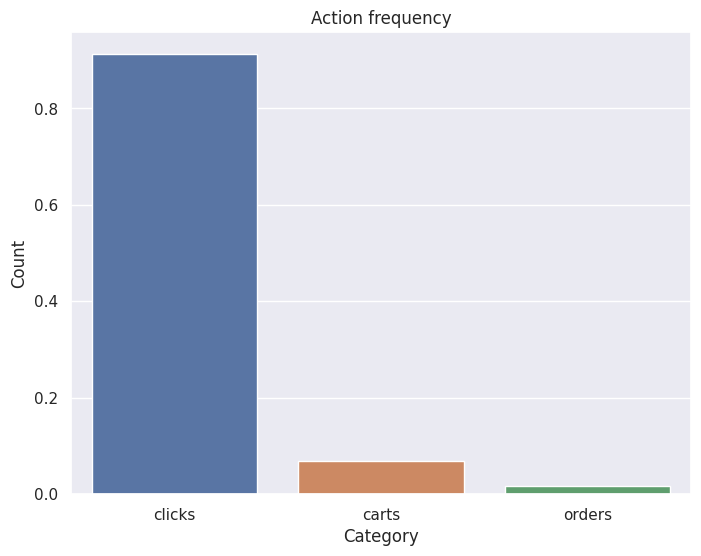

In [ ]:
total_actions = sum(overall_action_counts.values())

plt.figure(figsize=(8,6))
sns.barplot(
    x=overall_action_counts.keys(),
    y=[i / total_actions for i in overall_action_counts.values()],
    hue=overall_action_counts.keys()
);
plt.title(f'Action frequency')
plt.ylabel('Count')
plt.xlabel('Category')
plt.show()

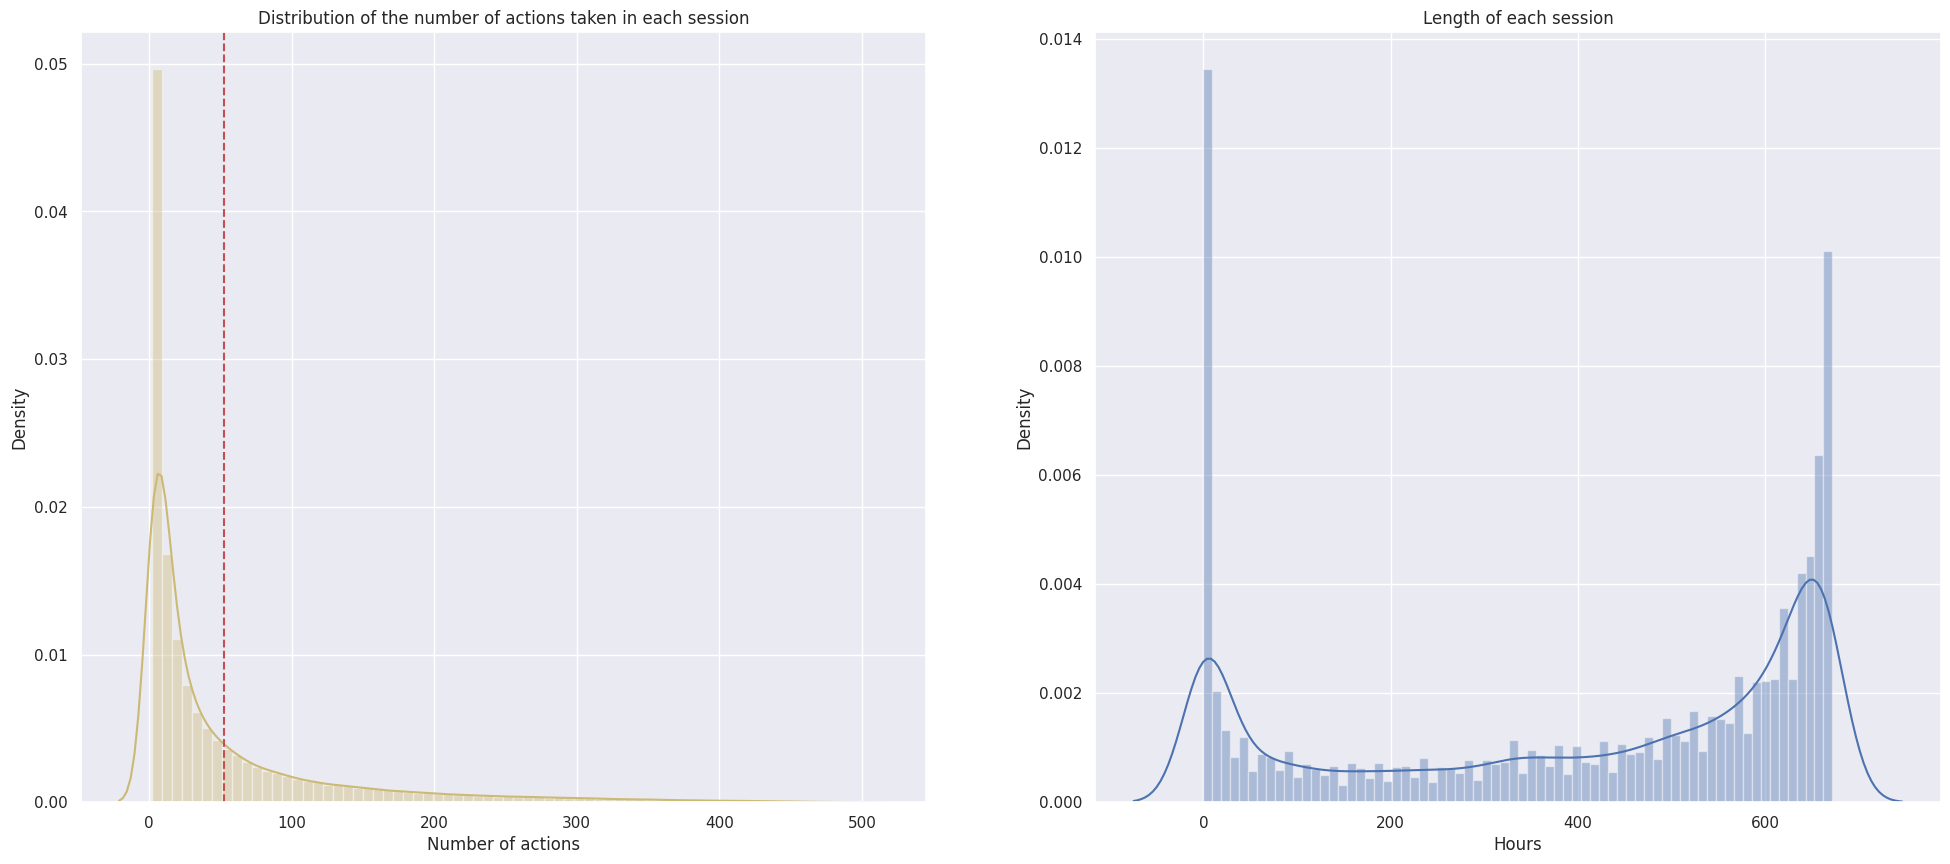

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(24, 10))

p = sns.distplot(sample_train_df['session_length_action'], color="y", bins=70, ax=ax[0], kde=True)
p.set_xlabel("Number of actions")
p.set_ylabel("Density")
p.set_title("Distribution of the number of actions taken in each session")
p.axvline(sample_train_df['session_length_action'].mean(), color='r', linestyle='--', label="Mean")

p = sns.distplot(sample_train_df['session_length_hours'], color="b", bins=70, ax=ax[1], kde=True)
p.set_xlabel("Hours")
p.set_ylabel("Density")
p.set_title("Length of each session");

In [ ]:
less_10_actions_df = sample_train_df[sample_train_df["session_length_action"] < 10]

print(f'{round(len(less_10_actions_df) / len(sample_train_df), 4) * 100}% of the sessions had less than 10 actions')

34.97% of the sessions had less than 10 actions


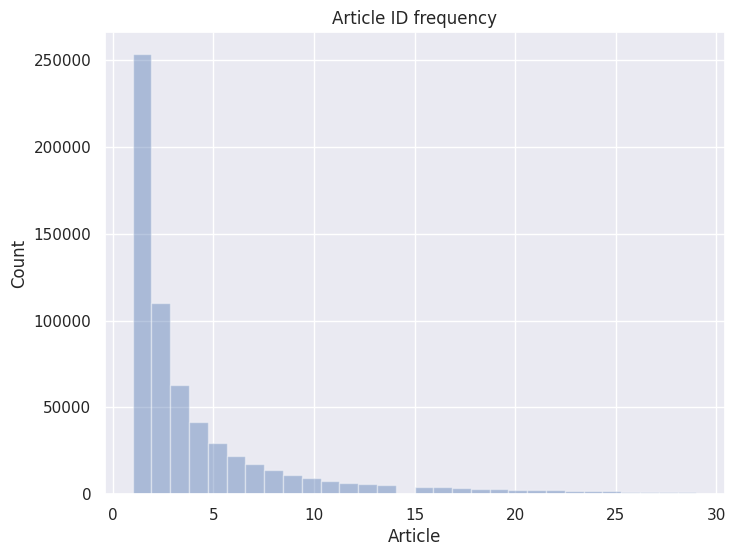

In [ ]:
article_id_freq = list(overall_article_id_counts.values())
cut_off = [i for i in article_id_freq if i < 30]

plt.figure(figsize=(8,6))
sns.distplot(cut_off, bins=30, kde=False);
plt.title(f'Article ID frequency')
plt.ylabel('Count')
plt.xlabel('Article')
plt.show()

In [ ]:
topN = 10

print(f'Frequency of most common articles: {sorted(list(overall_article_id_counts.values()))[-topN:]}')

print(f'IDs for those common articles: {nlargest(topN, overall_article_id_counts, key = overall_article_id_counts.get)}')

Frequency of most common articles: [2180, 2207, 2407, 2614, 2655, 2863, 2900, 3046, 3299, 3716]
IDs for those common articles: [29735, 832192, 1733943, 108125, 1603001, 554660, 166037, 80222, 247240, 332654]


### Baseline

In [ ]:
# Идея
# Этот baseline:
# 1. Берёт товары, уже встречавшиеся в тестовой сессии.
# 2. Сортирует их по частоте внутри этой сессии.
# 3. Оставляет top-20.
# 4. Если товаров меньше 20, дополняет глобально популярными товарами из train.
# 5. Делает предсказания отдельно для clicks, carts и order.

In [ ]:
sample_test_df = pd.read_json(TEST_PATH, lines=True, nrows=100000)

In [ ]:
sample_test_df.head()

,session,events
0,12899779,"[{'aid': 59625, 'ts': 1661724000278, 'type': '..."
1,12899780,"[{'aid': 1142000, 'ts': 1661724000378, 'type':..."
2,12899781,"[{'aid': 141736, 'ts': 1661724000559, 'type': ..."
3,12899782,"[{'aid': 1669402, 'ts': 1661724000568, 'type':..."
4,12899783,"[{'aid': 255297, 'ts': 1661724000572, 'type': ..."


In [ ]:
sample_submission_df = pd.read_csv(SAMPLE_SUB_PATH)

In [ ]:
sample_submission_df.head()

,session_type,labels
0,12899779_clicks,129004 126836 118524
1,12899779_carts,129004 126836 118524
2,12899779_orders,129004 126836 118524
3,12899780_clicks,129004 126836 118524
4,12899780_carts,129004 126836 118524


In [ ]:
# Прочитать TRAIN_PATH чанками
# Использовать только несколько первых чанков, чтобы ускорить вычисления
#
# Создать 3 списка:
# - clicks_article_list
# - carts_article_list
# - orders_article_list
#
# Для каждого события в каждой сессии:
#   если type == 'clicks'  -> добавить aid в clicks_article_list
#   если type == 'carts'   -> добавить aid в carts_article_list
#   иначе                  -> добавить aid в orders_article_list

In [ ]:
ACTION_TYPES = ['clicks', 'carts', 'orders']

CHUNK_SIZE = 10000

In [ ]:
train_chunks = pd.read_json(TEST_PATH, lines=True, chunksize=CHUNK_SIZE)

train_aid_by_action_type_cnt = {k: [] for k in ACTION_TYPES}

for i, c in enumerate(train_chunks, start=1):
    sample_train_df = c
    sample_train_df.set_index("session", drop=True, inplace=True)

    for session in sample_train_df["events"]:
        for event in session:
            train_aid_by_action_type_cnt[event["type"]].append(event["aid"])

    # if i == 3:
    #     break

In [ ]:
train_aid_by_action_type_freq = {
    k: Counter(v)
    for k, v in train_aid_by_action_type_cnt.items()
}

In [ ]:
topN = 20

train_aid_by_action_type_top = {
    k: nlargest(topN, v)
    for k, v in train_aid_by_action_type_freq.items()
}

In [ ]:
for action in ACTION_TYPES:
    print(f'Most frequent articles for {action}: {train_aid_by_action_type_top[action]}')

Most frequent articles for clicks: [1855600, 1855599, 1855594, 1855593, 1855592, 1855591, 1855589, 1855584, 1855583, 1855582, 1855576, 1855574, 1855572, 1855571, 1855569, 1855568, 1855567, 1855565, 1855562, 1855552]
Most frequent articles for carts: [1855600, 1855594, 1855593, 1855591, 1855589, 1855584, 1855572, 1855562, 1855547, 1855543, 1855541, 1855533, 1855526, 1855525, 1855508, 1855500, 1855499, 1855498, 1855497, 1855495]
Most frequent articles for orders: [1855572, 1855508, 1855499, 1855485, 1855431, 1855339, 1855333, 1855289, 1855280, 1855266, 1855113, 1855043, 1855042, 1855029, 1855019, 1855016, 1854933, 1854920, 1854872, 1854862]


In [ ]:
# TODO:
# Пройти по всем чанкам test_data
#
# Для каждой сессии:
#   1. взять actions = row['events']
#   2. собрать все aid в article_id_list
#   3. через Counter посчитать частоты aid в текущей сессии
#   4. взять top-20 самых частых article_id -> top_articles
#
# Затем для каждого action в ['clicks', 'carts', 'order']:
#   5. если top_articles короче 20, дополнить frequent_articles[action]
#   6. преобразовать итоговый список aid в строку через пробел
#   7. добавить строку в preds

In [ ]:
test_chunks = pd.read_json(TEST_PATH, lines=True, chunksize=CHUNK_SIZE)

preds = []

for i, c in enumerate(test_chunks, start=1):
    sample_test_df = c
    sample_test_df.set_index("session", drop=True, inplace=True)

    for session, row in sample_test_df.iterrows():
        test_aid_by_action_type_cnt = {k: [] for k in ACTION_TYPES}

        for event in row["events"]:
            test_aid_by_action_type_cnt[event["type"]].append(event["aid"])

        test_aid_by_action_type_freq = {
            k: Counter(v)
            for k, v in test_aid_by_action_type_cnt.items()
        }

        test_aid_by_action_type_top = {
            k: nlargest(topN, v)
            for k, v in test_aid_by_action_type_freq.items()
        }

        for action in ACTION_TYPES:
            current = list(dict.fromkeys(test_aid_by_action_type_top[action]))
            aid_cnt = len(test_aid_by_action_type_top[action])

            if len(current) < topN:
                needed = topN - len(current)

                for aid in nlargest(topN, train_aid_by_action_type_top[action]):
                    if aid not in current:
                        current.append(aid)
                        needed -= 1
                        if needed == 0:
                            break

                test_aid_by_action_type_top[action] = current

            # print(f'Most frequent articles for {action}: {current[:5]}..., total: {len(current)}')

            aid_line = " ".join(list(map(str, current)))
            preds.append([str(session) + "_" + action, aid_line])

        # print(*preds, sep="\n")

        # break
    # break

In [ ]:
preds_df = pd.DataFrame(preds, columns=["session_type", "labels"])

In [ ]:
preds_df.head()

,session_type,labels
0,12899779_clicks,59625 1855600 1855599 1855594 1855593 1855592 ...
1,12899779_carts,1855600 1855594 1855593 1855591 1855589 185558...
2,12899779_orders,1855572 1855508 1855499 1855485 1855431 185533...
3,12899780_clicks,1142000 973453 736515 582732 1855600 1855599 1...
4,12899780_carts,1855600 1855594 1855593 1855591 1855589 185558...


In [ ]:
preds_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5015409 entries, 0 to 5015408
Data columns (total 2 columns):
 #   Column        Dtype 
---  ------        ----- 
 0   session_type  object
 1   labels        object
dtypes: object(2)
memory usage: 76.5+ MB


In [ ]:
preds_df.to_csv(SUB_PATH, index=False)

In [ ]:
!kaggle competitions submit \
    -c otto-recommender-system \
    -f {SUB_PATH} \
    -m "baseline submission"

100% 837M/837M [00:09<00:00, 91.5MB/s]
Successfully submitted to OTTO – Multi-Objective Recommender System

In [ ]:
!kaggle competitions submissions -c otto-recommender-system

fileName        date                        description          status                     publicScore  privateScore  
--------------  --------------------------  -------------------  -------------------------  -----------  ------------  
submission.csv  2026-04-10 08:13:45.470000  baseline submission  SubmissionStatus.COMPLETE  0.06187      0.06190       


### Двухуровневая модель

#### 0. Воспроизведение датасета для обучения

Чтобы каждый раз не проверять качество модели сабмитом на kaggle, стоит из train датасета сформировать локальный датасет для контроля качества модели (для этого также придется будет воспроизвести целевую метрику Recall@20)

In [ ]:
ACTION_TYPES = ["clicks", "carts", "orders"]

TYPE2ID = {k: i for i, k in enumerate(ACTION_TYPES)}

ID2TYPE = {v: k for k, v in TYPE2ID.items()}

CHUNK_SIZE = 10000

TARGET_SESSIONS = 30_000

SAMPLE_PROB = 0.1

Датасет будем формировать, используя концепцию OOT валидации. Для этого каждую сессию, если она больше заданного размера, будем делить на 2 части - левую - train, и правую - val. Так как исхрдный датасэт занимает 11 Гб, насэмплируем датасет адекватного размера для тестов

In [ ]:
rows = []

with open(TRAIN_PATH) as f:
    for line in tqdm(f, desc="Sampling sessions"):
        if len(rows) >= TARGET_SESSIONS:
            break

        if random.random() < SAMPLE_PROB:
            data = json.loads(line)

            rows.append({
                "session": data["session"],
                "events": data["events"]
            })

sample_df = pd.DataFrame(rows)
sample_df

Sampling sessions: 0it [00:00, ?it/s]

,session,events
0,15,"[{'aid': 1464271, 'ts': 1659304800257, 'type':..."
1,17,"[{'aid': 120548, 'ts': 1659304800325, 'type': ..."
2,19,"[{'aid': 1248752, 'ts': 1659304800333, 'type':..."
3,22,"[{'aid': 1634695, 'ts': 1659304800374, 'type':..."
4,29,"[{'aid': 1437414, 'ts': 1659304800483, 'type':..."
...,...,...
29995,298864,"[{'aid': 358111, 'ts': 1659342239965, 'type': ..."
29996,298866,"[{'aid': 409620, 'ts': 1659342240007, 'type': ..."
29997,298888,"[{'aid': 245831, 'ts': 1659342240932, 'type': ..."
29998,298903,"[{'aid': 1196256, 'ts': 1659342241934, 'type':..."


Теперь поделим на "до" и "после" для формирования таргетов. Левая часть - префикс - будет представлять собой последовательность событий как в TRAIN датасете OTTO. Правая часть будет содержжать истинные таргеты, которые модель должна предсказывать

In [ ]:
valid_prefix_rows = []
valid_label_rows = []

for session, events in tqdm(sample_df.itertuples(index=False), total=len(sample_df), desc="Splitting sessions"):
    n = len(events)

    # фильтр коротких сессий
    if n < 2:
        continue

    split_idx = n // 2

    # защита от крайних случаев
    if split_idx == 0 or split_idx == n:
        continue

    prefix = events[:split_idx]
    suffix = events[split_idx:]

    # формирование таргетов
    clicks = None
    carts = []
    orders = []

    for event in suffix:
        if event["type"] == "clicks":
            clicks = event["aid"]
        elif event["type"] == "carts":
            carts.append(event["aid"])
        elif event["type"] == "orders":
            orders.append(event["aid"])

    # удаление дубликатов с сохранением порядка
    carts = list(dict.fromkeys(carts))
    orders = list(dict.fromkeys(orders))

    valid_prefix_rows.append({
        "session": session,
        "events": prefix
    })

    valid_label_rows.append({
        "session": session,
        "clicks": clicks,
        "carts": carts,
        "orders": orders,
    })

valid_prefix_df = pd.DataFrame(valid_prefix_rows)
valid_labels_df = pd.DataFrame(valid_label_rows)

print(valid_prefix_df.shape, valid_labels_df.shape)

Splitting sessions:   0%|          | 0/30000 [00:00<?, ?it/s]

(30000, 2) (30000, 4)


In [ ]:
valid_prefix_df.head()

,session,events
0,15,"[{'aid': 1464271, 'ts': 1659304800257, 'type':..."
1,17,"[{'aid': 120548, 'ts': 1659304800325, 'type': ..."
2,19,"[{'aid': 1248752, 'ts': 1659304800333, 'type':..."
3,22,"[{'aid': 1634695, 'ts': 1659304800374, 'type':..."
4,29,"[{'aid': 1437414, 'ts': 1659304800483, 'type':..."


In [ ]:
valid_labels_df.head()

,session,clicks,carts,orders
0,15,1559698.0,"[326181, 933465, 791627, 11972]",[791627]
1,17,1782639.0,[],[]
2,19,1315233.0,"[719255, 1006109, 1213426, 165455, 383546, 228...","[1213426, 1006109, 165455, 719255, 383546, 228..."
3,22,978745.0,[],[]
4,29,593311.0,"[1069234, 86667, 1211725, 1639437, 524133]",[]


In [ ]:
print("Clicks coverage:", valid_labels_df["clicks"].notna().mean())
print("Carts coverage:", (valid_labels_df["carts"].apply(len) > 0).mean())
print("Orders coverage:", (valid_labels_df["orders"].apply(len) > 0).mean())

Clicks coverage: 0.9992
Carts coverage: 0.39386666666666664
Orders coverage: 0.2058


Также воспроизведем Функции для расчета целевых метрик

In [ ]:
def hit_at_k(preds, target, k=20):
    if target is None:
        return None
    return float(target in preds[:k])


def recall_at_k(preds, targets, k=20):
    if not targets:
        return None
    pred_set = set(preds[:k])
    target_set = set(targets)
    return len(pred_set & target_set) / min(len(target_set), k)


def otto_metric(predictions, labels_df, k=20, weights=None):
    if weights is None:
        weights = {
            "clicks": 0.10,
            "carts": 0.30,
            "orders": 0.60,
        }

    click_scores = []
    cart_scores = []
    order_scores = []

    for _, row in labels_df.iterrows():
        session = row["session"]

        if session not in predictions:
            continue

        session_preds = predictions[session]

        click_score = hit_at_k(
            session_preds.get("clicks", []),
            row["clicks"],
            k=k
        )

        if click_score is not None:
            click_scores.append(click_score)

        cart_score = recall_at_k(
            session_preds.get("carts", []),
            row["carts"],
            k=k
        )
        if cart_score is not None:
            cart_scores.append(cart_score)

        order_score = recall_at_k(
            session_preds.get("orders", []),
            row["orders"],
            k=k
        )
        if order_score is not None:
            order_scores.append(order_score)

    mean_clicks = np.mean(click_scores) if click_scores else 0.0
    mean_carts = np.mean(cart_scores) if cart_scores else 0.0
    mean_orders = np.mean(order_scores) if order_scores else 0.0

    total = (
        weights["clicks"] * mean_clicks +
        weights["carts"] * mean_carts +
        weights["orders"] * mean_orders
    )

    return {
        "clicks_recall@20": mean_clicks,
        "carts_recall@20": mean_carts,
        "orders_recall@20": mean_orders,
        "weighted_recall@20": total,
    }

#### 1. Генерация кандидатов

Первым делом в качестве фоллбэк эвристики сформируем топ товаров по разным событиям, а также глобальный топ

In [ ]:
global_clicks = Counter()
global_carts = Counter()
global_orders = Counter()
global_all = Counter()

for events in tqdm(sample_df["events"], desc="Counting popularity"):
    for e in events:
        aid = e["aid"]
        t = e["type"]

        global_all[aid] += 1

        if t == "clicks":
            global_clicks[aid] += 1
        elif t == "carts":
            global_carts[aid] += 1
        elif t == "orders":
            global_orders[aid] += 1

top_clicks = [aid for aid, _ in global_clicks.most_common(100)]
top_carts = [aid for aid, _ in global_carts.most_common(100)]
top_orders = [aid for aid, _ in global_orders.most_common(100)]
top_all = [aid for aid, _ in global_all.most_common(100)]

Counting popularity:   0%|          | 0/30000 [00:00<?, ?it/s]

Следующая эвристика - это "товары, которые берут вместе". Построим co-visitation матрицу для N последних событий каждой сессии. После этого полученную матрицу обрежем, оставив в ней только топ по пересечениям

In [ ]:
from collections import defaultdict

COVIS_TOPN = 40  # топ N объектов для covis "матрицы"
PAIR_WINDOW = 20 # последние N объектов в сессии

covis_counter = defaultdict(Counter)

for events in tqdm(sample_df["events"], desc="Building co-visitation"):
    aids = [e["aid"] for e in events]

    # удаление дубликатов с сохранением порядка
    uniq_aids = list(dict.fromkeys(aids))

    # учитываем последние N товаров в сессии
    uniq_aids = uniq_aids[-PAIR_WINDOW:]

    for i, aid_i in enumerate(uniq_aids):
        for j, aid_j in enumerate(uniq_aids):
            if i == j:
                continue
            covis_counter[aid_i][aid_j] += 1

covis_top = {
    aid: [nbr for nbr, _ in nbrs.most_common(COVIS_TOPN)]
    for aid, nbrs in tqdm(covis_counter.items(), desc="Compressing co-visitation")
}

Building co-visitation:   0%|          | 0/30000 [00:00<?, ?it/s]

Compressing co-visitation:   0%|          | 0/179882 [00:00<?, ?it/s]

Теперь можем написать простую функцию для отбора кандидатов для одной сессии

In [ ]:
def generate_candidates_for_session(
    events,
    action_type,
    covis_top,
    top_clicks,
    top_carts,
    top_orders,
):
    aids = [e["aid"] for e in events]
    types = [e["type"] for e in events]

    uniq_aids = list(dict.fromkeys(aids))
    uniq_recent = uniq_aids[::-1]  # переворачиваем

    candidates = {}

    def ensure_candidate(aid):
        if aid not in candidates:
            candidates[aid] = {
                "aid": aid,
                "in_session": 0,
                "session_count": 0,
                "last_pos_from_end": 9999,
                "from_covis": 0,
                "covis_rank": 9999,
                "from_fallback": 0,
            }
        return candidates[aid]

    # 1. session-based
    for pos_from_end, aid in enumerate(reversed(aids)):
        row = ensure_candidate(aid)
        row["in_session"] = 1
        row["session_count"] += 1
        row["last_pos_from_end"] = min(row["last_pos_from_end"], pos_from_end)

    # 2. co-visitation
    for src_aid in uniq_recent[:10]:
        nbrs = covis_top.get(src_aid, [])
        for rank, nbr in enumerate(nbrs):
            row = ensure_candidate(nbr)
            row["from_covis"] = 1
            row["covis_rank"] = min(row["covis_rank"], rank)

    # 3. fallback
    if action_type == "clicks":
        fallback = top_clicks
    elif action_type == "carts":
        fallback = top_carts
    else:
        fallback = top_orders

    for aid in fallback:
        row = ensure_candidate(aid)
        row["from_fallback"] = 1

    # heuristic score
    for aid, row in candidates.items():
        score = 0.0

        if row["in_session"]:
            score += 100
            score += 5 * row["session_count"]
            score += max(0, 20 - row["last_pos_from_end"])

        if row["from_covis"]:
            score += max(0, 40 - row["covis_rank"])

        if row["from_fallback"]:
            score += 1

        row["score"] = score

    return candidates.values()

In [ ]:
def build_predictions_baseline(
    valid_prefix_df,
    covis_top,
    top_clicks,
    top_carts,
    top_orders,
    topk=20,
    candidate_topk=100,
):
    predictions = {}

    for session, events in tqdm(
        valid_prefix_df[["session", "events"]].itertuples(index=False),
        total=len(valid_prefix_df),
        desc="Baseline inference",
    ):
        preds = {}

        for action in ACTION_TYPES:
            candidates = generate_candidates_for_session(
                events=events,
                action_type=action,
                covis_top=covis_top,
                top_clicks=top_clicks,
                top_carts=top_carts,
                top_orders=top_orders,
            )

            ranked = sorted(candidates, key=lambda x: -x["score"])
            ranked = ranked[:candidate_topk]

            preds[action] = [row["aid"] for row in ranked[:topk]]

        predictions[session] = preds

    return predictions

In [ ]:
predictions = build_predictions_baseline(
    valid_prefix_df=valid_prefix_df,
    covis_top=covis_top,
    top_clicks=top_clicks,
    top_carts=top_carts,
    top_orders=top_orders,
    topk=20,
    candidate_topk=100,
)

otto_metric(predictions, valid_labels_df, k=20)

Baseline inference:   0%|          | 0/30000 [00:00<?, ?it/s]

{'clicks_recall@20': np.float64(0.40123333333333333),
 'carts_recall@20': np.float64(0.3300706703143483),
 'orders_recall@20': np.float64(0.42660870120136807),
 'weighted_recall@20': np.float64(0.3951097551484587)}

#### 2. Ранжирование кандидатов

Попробуем обучить деревянную модель для ранжирования отобранных кандидатов. Сначала создадим train датасет

In [ ]:
labels_dict = {
    row["session"]: row
    for _, row in valid_labels_df.iterrows()
}

In [ ]:
rows = []

for session, events in tqdm(
    valid_prefix_df[["session", "events"]].itertuples(index=False),
    total=len(valid_prefix_df),
    desc="Building training dataset"
):
    candidates = generate_candidates_for_session(
        events=events,
        action_type="clicks",  # сначала только clicks
        covis_top=covis_top,
        top_clicks=top_clicks,
        top_carts=top_carts,
        top_orders=top_orders,
    )

    ranked = sorted(candidates, key=lambda x: -x["score"])
    ranked = ranked[:100]

    # --- target ---
    target_click = labels_dict[session]["clicks"]

    for row in ranked:
        aid = row["aid"]

        rows.append({
            "session": session,
            "aid": aid,

            # --- features ---
            "in_session": row["in_session"],
            "session_count": row["session_count"],
            "last_pos_from_end": row["last_pos_from_end"],
            "from_covis": row["from_covis"],
            "covis_rank": row["covis_rank"],
            "from_fallback": row["from_fallback"],

            # --- target ---
            "target": int(aid == target_click)
        })

train_df = pd.DataFrame(rows)
train_df

Building training dataset:   0%|          | 0/30000 [00:00<?, ?it/s]

,session,aid,in_session,session_count,last_pos_from_end,from_covis,covis_rank,from_fallback,target
0,15,1409430,1,5,0,0,9999,0,0
1,15,354056,1,7,21,0,9999,0,0
2,15,461590,1,1,1,0,9999,0,0
3,15,1421518,1,1,3,0,9999,0,0
4,15,1574169,1,1,5,0,9999,0,0
...,...,...,...,...,...,...,...,...,...
2999995,299370,530377,0,0,9999,0,9999,1,0
2999996,299370,1788615,0,0,9999,0,9999,1,0
2999997,299370,1236775,0,0,9999,0,9999,1,0
2999998,299370,714524,0,0,9999,0,9999,1,0


In [ ]:
train_df["target"].mean()

np.float64(0.006556)

In [ ]:
train, valid = train_test_split(train_df, test_size=0.2, random_state=42)

In [ ]:
features = [
    "in_session",
    "session_count",
    "last_pos_from_end",
    "from_covis",
    "covis_rank",
    "from_fallback",
]

train_data = lgb.Dataset(train[features], label=train["target"])
valid_data = lgb.Dataset(valid[features], label=valid["target"])

params = {
    "objective": "binary",
    "metric": "auc",
    "learning_rate": 0.1,
    "num_leaves": 64,
    "verbose": -1,
}

model = lgb.train(
    params,
    train_data,
    valid_sets=[valid_data],
    num_boost_round=200,
    callbacks=[
        lgb.early_stopping(stopping_rounds=20)
    ]
)

Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[8]	valid_0's auc: 0.791268


In [ ]:
def build_predictions_lgb(
    model,
    features,
    valid_prefix_df,
    covis_top,
    top_clicks,
    top_carts,
    top_orders,
    topk=20,
    candidate_topk=100,
):
    all_rows = []

    for session, events in tqdm(
        valid_prefix_df[["session", "events"]].itertuples(index=False),
        total=len(valid_prefix_df),
        desc="Collecting candidates",
    ):
        for action in ACTION_TYPES:
            candidates = generate_candidates_for_session(
                events=events,
                action_type=action,
                covis_top=covis_top,
                top_clicks=top_clicks,
                top_carts=top_carts,
                top_orders=top_orders,
            )

            candidates = sorted(candidates, key=lambda x: -x["score"])[:candidate_topk]

            for row in candidates:
                all_rows.append({
                    "session": session,
                    "action": action,
                    "aid": row["aid"],

                    # --- features ---
                    "in_session": row["in_session"],
                    "session_count": row["session_count"],
                    "last_pos_from_end": row["last_pos_from_end"],
                    "from_covis": row["from_covis"],
                    "covis_rank": row["covis_rank"],
                    "from_fallback": row["from_fallback"],
                })

    df = pd.DataFrame(all_rows)

    df["score"] = model.predict(df[features])

    df = df.sort_values(["session", "action", "score"], ascending=[True, True, False])

    predictions = {}

    for (session, action), group in df.groupby(["session", "action"]):
        top_items = group["aid"].head(topk).tolist()

        if session not in predictions:
            predictions[session] = {}

        predictions[session][action] = top_items

    return predictions

In [ ]:
predictions = build_predictions_lgb(
    model=model,
    features=features,
    valid_prefix_df=valid_prefix_df,
    covis_top=covis_top,
    top_clicks=top_clicks,
    top_carts=top_carts,
    top_orders=top_orders,
    topk=20,
    candidate_topk=100,
)

otto_metric(predictions, valid_labels_df, k=20)

{'clicks_recall@20': np.float64(0.41633333333333333),
 'carts_recall@20': np.float64(0.29041244741403016),
 'orders_recall@20': np.float64(0.3302339782708234),
 'weighted_recall@20': np.float64(0.3268974545200364)}

#### Попытка улучшить генерацию кандидатов

В целом, то что МЛ ранжирование отработало хуже, чем обычная сортировка по введенным выше эвристикам - очень даже закономерно. Возможно, у меня пока очень мало фичей. Но помимо этого есть моменты, которые можно улучшить

Как минимум, стоит отказаться от эвристики "топ популярных" в пользу более полезных - в частности - улучшить генерацию co-visitation матриц - добавить учет временных окон, разделение на типы событий

In [ ]:
from collections import defaultdict

def build_covisitation(
    events_list,
    action_type=None,   # None / "clicks" / "carts" / "orders"
    time_window=24 * 60 * 60,  # секунды
    max_session_len=30,
    topk=40,
):
    covis = defaultdict(Counter)

    for events in tqdm(events_list, desc=f"Building covis ({action_type})"):

        # отбор по типу
        if action_type:
            events = [e for e in events if e["type"] == action_type]
            if len(events) < 2:
                continue

        # ограничение длины сессии (по количеству товаров)
        events = events[-max_session_len:]

        aids = [e["aid"] for e in events]
        ts = [e["ts"] // 1000 for e in events]  # в секунды

        for i in range(len(aids)):
            for j in range(len(aids)):
                if i == j:
                    continue

                # ограничение длины сессии (по временному окну)
                if abs(ts[i] - ts[j]) > time_window:
                    continue

                # введение весового коэффициента значимости
                # (последние наиболее важны)
                dist = abs(ts[i] - ts[j])
                weight = 1 / (1 + dist)

                covis[aids[i]][aids[j]] += weight

    # сжатие
    covis_top = {
        aid: cnt.most_common(topk)
        for aid, cnt in tqdm(covis.items(), desc="Compressing covis")
    }

    return covis_top

In [ ]:
co_click = build_covisitation(
    sample_df["events"],
    action_type="clicks",
    topk=40,
)

co_cart = build_covisitation(
    sample_df["events"],
    action_type="carts",
    topk=40,
)

co_buy = build_covisitation(
    sample_df["events"],
    action_type="orders",
    topk=40,
)

Building covis (clicks):   0%|          | 0/30000 [00:00<?, ?it/s]

Compressing covis:   0%|          | 0/175443 [00:00<?, ?it/s]

Building covis (carts):   0%|          | 0/30000 [00:00<?, ?it/s]

Compressing covis:   0%|          | 0/51791 [00:00<?, ?it/s]

Building covis (orders):   0%|          | 0/30000 [00:00<?, ?it/s]

Compressing covis:   0%|          | 0/17885 [00:00<?, ?it/s]

Обновим генерацию кандидатов для одной сессии

In [ ]:
def generate_candidates_for_session_v2(
    events,
    action_type,
    co_click,
    co_cart,
    co_buy,
    candidate_topk=100,
):
    aids = [e["aid"] for e in events]
    types = [e["type"] for e in events]

    uniq = list(dict.fromkeys(aids[::-1]))

    candidates = {}

    def add_candidate(aid, source):
        if aid not in candidates:
            candidates[aid] = {
                "aid": aid,
                "in_session": 0,
                "from_co_click": 0,
                "from_co_cart": 0,
                "from_co_buy": 0,
                "recency": 9999,
            }

        candidates[aid][source] = 1

    # in_session
    for pos, aid in enumerate(reversed(aids)):
        add_candidate(aid, "in_session")

        candidates[aid]["recency"] = min(
            candidates[aid]["recency"],
            pos
        )

    # co-click
    for aid in uniq[:5]:
        for nbr, score in co_click.get(aid, []):
            add_candidate(nbr, "from_co_click")

    # co-cart
    cart_items = [a for a, t in zip(aids, types) if t == "carts"]
    for aid in cart_items[-3:]:
        for nbr, score in co_cart.get(aid, []):
            add_candidate(nbr, "from_co_cart")

    # co-buy
    order_items = [a for a, t in zip(aids, types) if t == "orders"]
    for aid in order_items[-3:]:
        for nbr, score in co_buy.get(aid, []):
            add_candidate(nbr, "from_co_buy")

    return list(candidates.values())

In [ ]:
def build_predictions_baseline_v2(
    valid_prefix_df,
    co_click,
    co_cart,
    co_buy,
    topk=20,
    candidate_topk=100,
):
    predictions = {}

    for session, events in tqdm(
        valid_prefix_df[["session", "events"]].itertuples(index=False),
        total=len(valid_prefix_df),
        desc="Baseline v2 inference",
    ):
        preds = {}

        for action in ACTION_TYPES:

            candidates = generate_candidates_for_session_v2(
                events=events,
                action_type=action,
                co_click=co_click,
                co_cart=co_cart,
                co_buy=co_buy,
                candidate_topk=candidate_topk,
            )

            # ранжирование
            for row in candidates:
                score = 0.0

                if row["in_session"]:
                    score += 100

                if row["from_co_click"]:
                    score += 10

                if row["from_co_cart"]:
                    score += 20

                if row["from_co_buy"]:
                    score += 30

                score += max(0, 20 - row["recency"])

                row["score"] = score

            # сортировка
            ranked = sorted(candidates, key=lambda x: -x["score"])
            ranked = ranked[:candidate_topk]

            preds[action] = [row["aid"] for row in ranked[:topk]]

        predictions[session] = preds

    return predictions

In [ ]:
predictions = build_predictions_baseline_v2(
    valid_prefix_df=valid_prefix_df,
    co_click=co_click,
    co_cart=co_cart,
    co_buy=co_buy,
)

otto_metric(predictions, valid_labels_df)

Baseline v2 inference:   0%|          | 0/30000 [00:00<?, ?it/s]

{'clicks_recall@20': np.float64(0.2812),
 'carts_recall@20': np.float64(0.36531593087376385),
 'orders_recall@20': np.float64(0.4481358867513111),
 'weighted_recall@20': np.float64(0.4065963113129158)}

Опять получаем неплохую базовую оценку целевой метрики до ранжирования кандидатов

Новая цель - обогатить модель ранжирования полезными фичами

#### Попытка улучшить ранжирование кандидатов

In [ ]:
import math

def build_features_for_candidates(events, candidates):
    aids = [e["aid"] for e in events]
    ts = [e["ts"] for e in events]

    session_len = len(aids)
    unique_items = len(set(aids))

    session_start = ts[0]
    session_end = ts[-1]

    session_duration = session_end - session_start
    session_duration_safe = max(session_duration, 1)

    avg_time_between = (
        (ts[-1] - ts[0]) / len(ts) if len(ts) > 1 else 0
    )

    session_density = session_len / session_duration_safe

    rows = []

    for row in candidates:
        aid = row["aid"]

        item_ts = []
        item_types = []

        for e in events:
            if e["aid"] == aid:
                item_ts.append(e["ts"])
                item_types.append(e["type"])

        if row["in_session"] and row["recency"] != 9999:
            recency = row["recency"]

            last_pos = session_len - 1 - recency
            relative_recency = recency / session_len if session_len > 0 else 0

            session_count = len(item_ts)
            first_pos = aids.index(aid)
            is_last = int(aids[-1] == aid)

            last_item_ts = item_ts[-1]
            time_since_last_event = min(session_end - last_item_ts, 1e9)

            recency_weighted_count = sum(
                1 / (1 + (session_end - t) / 1e5)
                for t in item_ts
            )

            last_item_type = item_types[-1]

        else:
            recency = -1
            last_pos = -1
            relative_recency = -1
            session_count = 0
            first_pos = -1
            is_last = 0
            time_since_last_event = -1
            recency_weighted_count = 0
            last_item_type = None

        rows.append({
            "aid": aid,

            "in_session": row["in_session"],
            "recency": recency,
            "from_co_click": row["from_co_click"],
            "from_co_cart": row["from_co_cart"],
            "from_co_buy": row["from_co_buy"],

            "session_len": session_len,
            "unique_items": unique_items,

            "session_count": session_count,
            "first_pos": first_pos,
            "last_pos": last_pos,
            "is_last": is_last,

            "time_since_last_event": time_since_last_event,
            "relative_recency": relative_recency,
            "session_duration": session_duration_safe,
            "avg_time_between": avg_time_between,
            "session_density": session_density,

            "recency_weighted_count": recency_weighted_count,
            "last_item_type": (
                0 if last_item_type == "clicks"
                else 1 if last_item_type == "carts"
                else 2 if last_item_type == "orders"
                else -1
            ),
        })

    return rows

In [ ]:
rows = []

for session, events in tqdm(
    valid_prefix_df[["session", "events"]].itertuples(index=False),
    total=len(valid_prefix_df),
    desc="Building train dataset"
):
    candidates = generate_candidates_for_session_v2(
        events=events,
        action_type="clicks",
        co_click=co_click,
        co_cart=co_cart,
        co_buy=co_buy,
    )

    target_click = labels_dict[session]["clicks"]

    feats = build_features_for_candidates(events, candidates)

    for r in feats:
        r["session"] = session
        r["target"] = int(r["aid"] == target_click)
        rows.append(r)

train_df = pd.DataFrame(rows)

In [ ]:
train_df

In [ ]:
train_df["target"].mean()

In [ ]:
features = [
    # retrieval
    "in_session",
    "recency",
    "from_co_click",
    "from_co_cart",
    "from_co_buy",

    # session
    "session_len",
    "unique_items",

    # interaction
    "session_count",
    "first_pos",
    "last_pos",
    "is_last",

    # time
    "time_since_last_event",
    "relative_recency",
    "session_duration",
    "avg_time_between",
    "session_density",

    # strength
    "recency_weighted_count",

    # categorical encoded
    "last_item_type",
]

# train_df[features].isna().sum()

In [ ]:
train_df.describe()

In [ ]:
from sklearn.model_selection import train_test_split

sessions = train_df["session"].unique()

train_sessions, valid_sessions = train_test_split(
    sessions,
    test_size=0.2,
    random_state=42
)

train = train_df[train_df["session"].isin(train_sessions)]
valid = train_df[train_df["session"].isin(valid_sessions)]

In [ ]:
train_data = lgb.Dataset(
    train[features],
    label=train["target"]
)

valid_data = lgb.Dataset(
    valid[features],
    label=valid["target"]
)

In [ ]:
params = {
    "objective": "binary",
    "metric": "auc",

    "learning_rate": 0.05,
    "num_leaves": 128,
    "max_depth": -1,

    "feature_fraction": 0.8,
    "bagging_fraction": 0.8,
    "bagging_freq": 1,

    "verbose": -1,
}

model = lgb.train(
    params,
    train_data,
    valid_sets=[valid_data],
    num_boost_round=1000,
    callbacks=[
        lgb.early_stopping(50),
        lgb.log_evaluation(50)
    ]
)

In [ ]:
lgb.plot_importance(model)

In [ ]:
def build_predictions_lgb_batched(
    model,
    features,
    valid_prefix_df,
    co_click,
    co_cart,
    co_buy,
    batch_size=5000,
    topk=20,
    candidate_topk=100,
):
    import pandas as pd

    predictions = {}
    n = len(valid_prefix_df)

    for start in tqdm(range(0, n, batch_size), desc="Batched inference"):
        end = min(start + batch_size, n)
        batch_df = valid_prefix_df.iloc[start:end]

        rows = []

        # Генерация кандидатов
        for session, events in batch_df[["session", "events"]].itertuples(index=False):

            for action in ACTION_TYPES:

                candidates = generate_candidates_for_session_v2(
                    events=events,
                    action_type=action,
                    co_click=co_click,
                    co_cart=co_cart,
                    co_buy=co_buy,
                    candidate_topk=candidate_topk,
                )

                feats = build_features_for_candidates(events, candidates)

                for r in feats:
                    r["session"] = session
                    r["action"] = action
                    rows.append(r)

        batch_features_df = pd.DataFrame(rows)

        # Предикт
        batch_features_df["score"] = model.predict(
            batch_features_df[features]
        )

        # Сортировка
        batch_features_df = batch_features_df.sort_values(
            ["session", "action", "score"],
            ascending=[True, True, False]
        )

        # Сбор top-k
        for (session, action), group in batch_features_df.groupby(["session", "action"]):
            top_items = group["aid"].head(topk).tolist()

            if session not in predictions:
                predictions[session] = {}

            predictions[session][action] = top_items

        # Очистка памяти
        del batch_features_df, rows

    return predictions

In [ ]:
predictions = build_predictions_lgb_batched(
    model=model,
    features=features,

    valid_prefix_df=valid_prefix_df,
    co_click=co_click,
    co_cart=co_cart,
    co_buy=co_buy,
    batch_size=1000,
)

otto_metric(predictions, valid_labels_df)

Batched inference:   0%|          | 0/30 [00:00<?, ?it/s]

{'clicks_recall@20': np.float64(0.29413333333333336),
 'carts_recall@20': np.float64(0.39044534306488277),
 'orders_recall@20': np.float64(0.47344321770683045),
 'weighted_recall@20': np.float64(0.43061286687689637)}

#### Обобщение моделей на тип события

In [ ]:
def build_train_df_for_action(
    valid_prefix_df,
    labels_dict,
    action_type,
    co_click,
    co_cart,
    co_buy,
):
    rows = []

    for session, events in tqdm(
        valid_prefix_df[["session", "events"]].itertuples(index=False),
        total=len(valid_prefix_df),
        desc=f"Building train dataset: {action_type}",
    ):
        candidates = generate_candidates_for_session_v2(
            events=events,
            action_type=action_type,
            co_click=co_click,
            co_cart=co_cart,
            co_buy=co_buy,
        )

        feats = build_features_for_candidates(events, candidates)

        label_row = labels_dict[session]

        if action_type == "clicks":
            target_value = label_row["clicks"]
            for r in feats:
                r["session"] = session
                r["target"] = int(r["aid"] == target_value)
                rows.append(r)

        elif action_type == "carts":
            target_values = set(label_row["carts"])
            for r in feats:
                r["session"] = session
                r["target"] = int(r["aid"] in target_values)
                rows.append(r)

        elif action_type == "orders":
            target_values = set(label_row["orders"])
            for r in feats:
                r["session"] = session
                r["target"] = int(r["aid"] in target_values)
                rows.append(r)

        else:
            raise ValueError(f"Unknown action_type: {action_type}")

    return pd.DataFrame(rows)

In [ ]:
train_df_clicks = build_train_df_for_action(
    valid_prefix_df=valid_prefix_df,
    labels_dict=labels_dict,
    action_type="clicks",
    co_click=co_click,
    co_cart=co_cart,
    co_buy=co_buy,
)

train_df_carts = build_train_df_for_action(
    valid_prefix_df=valid_prefix_df,
    labels_dict=labels_dict,
    action_type="carts",
    co_click=co_click,
    co_cart=co_cart,
    co_buy=co_buy,
)

train_df_orders = build_train_df_for_action(
    valid_prefix_df=valid_prefix_df,
    labels_dict=labels_dict,
    action_type="orders",
    co_click=co_click,
    co_cart=co_cart,
    co_buy=co_buy,
)

Building train dataset: clicks:   0%|          | 0/30000 [00:00<?, ?it/s]

Building train dataset: carts:   0%|          | 0/30000 [00:00<?, ?it/s]

Building train dataset: orders:   0%|          | 0/30000 [00:00<?, ?it/s]

In [ ]:
print("clicks:", train_df_clicks.shape, train_df_clicks["target"].mean())
print("carts :", train_df_carts.shape, train_df_carts["target"].mean())
print("orders:", train_df_orders.shape, train_df_orders["target"].mean())

clicks: (2334404, 21) 0.00476609875582804
carts : (2334404, 21) 0.009442667164723844
orders: (2334404, 21) 0.004572044941663911


In [ ]:
def train_lgb_for_action(train_df, features, action_name):
    sessions = train_df["session"].unique()

    train_sessions, valid_sessions = train_test_split(
        sessions,
        test_size=0.2,
        random_state=42,
    )

    train_part = train_df[train_df["session"].isin(train_sessions)]
    valid_part = train_df[train_df["session"].isin(valid_sessions)]

    train_data = lgb.Dataset(
        train_part[features],
        label=train_part["target"]
    )
    valid_data = lgb.Dataset(
        valid_part[features],
        label=valid_part["target"]
    )

    params = {
        "objective": "binary",
        "metric": "auc",
        "learning_rate": 0.05,
        "num_leaves": 128,
        "feature_fraction": 0.8,
        "bagging_fraction": 0.8,
        "bagging_freq": 1,
        "verbose": -1,
    }

    print(f"Training {action_name}...")
    model = lgb.train(
        params,
        train_data,
        valid_sets=[valid_data],
        num_boost_round=1000,
        callbacks=[
            lgb.early_stopping(50),
            lgb.log_evaluation(50),
        ],
    )

    return model

In [ ]:
model_clicks = train_lgb_for_action(train_df_clicks, features, "clicks")
model_carts = train_lgb_for_action(train_df_carts, features, "carts")
model_orders = train_lgb_for_action(train_df_orders, features, "orders")

Training clicks...
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.817977
[100]	valid_0's auc: 0.818365
Early stopping, best iteration is:
[73]	valid_0's auc: 0.818918
Training carts...
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.887344
Early stopping, best iteration is:
[29]	valid_0's auc: 0.887766
Training orders...
Training until validation scores don't improve for 50 rounds
[50]	valid_0's auc: 0.925404
Early stopping, best iteration is:
[25]	valid_0's auc: 0.926548


In [ ]:
models = {
    "clicks": model_clicks,
    "carts": model_carts,
    "orders": model_orders,
}

In [ ]:
def build_predictions_lgb_batched_multi(
    models,
    features,
    valid_prefix_df,
    co_click,
    co_cart,
    co_buy,
    batch_size=1000,
    topk=20,
    candidate_topk=100,
):
    predictions = {}
    n = len(valid_prefix_df)

    for start in tqdm(range(0, n, batch_size), desc="Batched multi-model inference"):
        end = min(start + batch_size, n)
        batch_df = valid_prefix_df.iloc[start:end]

        rows = []

        for session, events in batch_df[["session", "events"]].itertuples(index=False):
            for action in ACTION_TYPES:
                candidates = generate_candidates_for_session_v2(
                    events=events,
                    action_type=action,
                    co_click=co_click,
                    co_cart=co_cart,
                    co_buy=co_buy,
                    candidate_topk=candidate_topk,
                )

                feats = build_features_for_candidates(events, candidates)

                for r in feats:
                    r["session"] = session
                    r["action"] = action
                    rows.append(r)

        batch_features_df = pd.DataFrame(rows)

        batch_features_df["score"] = 0.0

        for action in ACTION_TYPES:
            mask = batch_features_df["action"] == action
            if mask.any():
                batch_features_df.loc[mask, "score"] = models[action].predict(
                    batch_features_df.loc[mask, features]
                )

        batch_features_df = batch_features_df.sort_values(
            ["session", "action", "score"],
            ascending=[True, True, False]
        )

        for (session, action), group in batch_features_df.groupby(["session", "action"]):
            top_items = group["aid"].head(topk).tolist()

            if session not in predictions:
                predictions[session] = {}

            predictions[session][action] = top_items

        del batch_features_df, rows

    return predictions

In [ ]:
predictions = build_predictions_lgb_batched_multi(
    models=models,
    features=features,
    valid_prefix_df=valid_prefix_df,
    co_click=co_click,
    co_cart=co_cart,
    co_buy=co_buy,
    batch_size=1000,
    topk=20,
    candidate_topk=100,
)

otto_metric(predictions, valid_labels_df, k=20)

Batched multi-model inference:   0%|          | 0/30 [00:00<?, ?it/s]

{'clicks_recall@20': np.float64(0.29413333333333336),
 'carts_recall@20': np.float64(0.4476250937305083),
 'orders_recall@20': np.float64(0.5166725425036622),
 'weighted_recall@20': np.float64(0.4737043869546832)}

In [ ]:
predictions = build_predictions_lgb_batched_multi(
    models=models,
    features=features,
    valid_prefix_df=valid_prefix_df,
    co_click=co_click,
    co_cart=co_cart,
    co_buy=co_buy,
    batch_size=1000,
    topk=20,
    candidate_topk=300,
)

otto_metric(predictions, valid_labels_df, k=20)

Batched multi-model inference:   0%|          | 0/30 [00:00<?, ?it/s]

{'clicks_recall@20': np.float64(0.29413333333333336),
 'carts_recall@20': np.float64(0.4476250937305083),
 'orders_recall@20': np.float64(0.5166725425036622),
 'weighted_recall@20': np.float64(0.4737043869546832)}

#### Финальный пайплайн

In [ ]:
def fill_to_topk(items, fallback, k=20):
    result = list(dict.fromkeys(items))

    for aid in fallback:
        if len(result) >= k:
            break
        if aid not in result:
            result.append(aid)

    return result[:k]

In [ ]:
def generate_click_candidates(events, covis_top, top_clicks):
    aids = [e["aid"] for e in events]

    uniq_recent = list(dict.fromkeys(aids))[::-1]

    candidates = {}

    def ensure(aid):
        if aid not in candidates:
            candidates[aid] = {
                "aid": aid,
                "in_session": 0,
                "session_count": 0,
                "last_pos_from_end": 9999,
                "covis_rank": 9999,
                "from_fallback": 0,
            }
        return candidates[aid]

    # session-based
    for pos, aid in enumerate(reversed(aids)):
        row = ensure(aid)
        row["in_session"] = 1
        row["session_count"] += 1
        row["last_pos_from_end"] = min(row["last_pos_from_end"], pos)

    # covis
    for src_aid in uniq_recent[:10]:
        for rank, nbr in enumerate(covis_top.get(src_aid, [])):
            row = ensure(nbr)
            row["covis_rank"] = min(row["covis_rank"], rank)

    # fallback
    for aid in top_clicks:
        row = ensure(aid)
        row["from_fallback"] = 1

    # scoring
    for row in candidates.values():
        score = 0.0

        if row["in_session"]:
            score += 100
            score += 5 * row["session_count"]
            score += max(0, 20 - row["last_pos_from_end"])

        score += max(0, 40 - row["covis_rank"])

        if row["from_fallback"]:
            score += 1

        row["score"] = score

    return candidates.values()


def generate_ml_candidates(events, co_click, co_cart, co_buy):
    aids = [e["aid"] for e in events]
    types = [e["type"] for e in events]

    uniq = list(dict.fromkeys(aids[::-1]))

    candidates = {}

    def add(aid):
        if aid not in candidates:
            candidates[aid] = {
                "aid": aid,
                "in_session": 0,
                "from_co_click": 0,
                "from_co_cart": 0,
                "from_co_buy": 0,
                "recency": 9999,
            }
        return candidates[aid]

    # in-session
    for pos, aid in enumerate(reversed(aids)):
        row = add(aid)
        row["in_session"] = 1
        row["recency"] = min(row["recency"], pos)

    # co-click
    for aid in uniq[:5]:
        for nbr, _ in co_click.get(aid, []):
            add(nbr)["from_co_click"] = 1

    # co-cart
    cart_items = [a for a, t in zip(aids, types) if t == "carts"]
    for aid in cart_items[-3:]:
        for nbr, _ in co_cart.get(aid, []):
            add(nbr)["from_co_cart"] = 1

    # co-buy
    order_items = [a for a, t in zip(aids, types) if t == "orders"]
    for aid in order_items[-3:]:
        for nbr, _ in co_buy.get(aid, []):
            add(nbr)["from_co_buy"] = 1

    return list(candidates.values())

In [ ]:
def build_predictions_hybrid_batched(
    models, features,
    valid_prefix_df,
    covis_top,
    top_clicks, top_carts, top_orders,
    co_click, co_cart, co_buy,
    batch_size=1000,
    topk=20,
    candidate_topk=100,
    quiet=False
):
    import pandas as pd

    predictions = {}
    n = len(valid_prefix_df)

    for start in tqdm(range(0, n, batch_size), desc="Hybrid", disable=quiet):
        end = min(start + batch_size, n)
        batch_df = valid_prefix_df.iloc[start:end]

        # 1. baseline (clicks)
        baseline_preds = {}

        for session, events in batch_df[["session", "events"]].itertuples(index=False):
            candidates = generate_click_candidates(
                events=events,
                covis_top=covis_top,
                top_clicks=top_clicks
            )

            ranked = sorted(candidates, key=lambda x: -x["score"])
            ranked = ranked[:candidate_topk]

            top_items = [row["aid"] for row in ranked[:topk]]

            baseline_preds[session] = fill_to_topk(
                top_items,
                top_clicks,
                topk
            )

        # 2. ML (carts + orders)
        ml_rows = []

        for session, events in batch_df[["session", "events"]].itertuples(index=False):
            for action in ["carts", "orders"]:
                candidates = generate_ml_candidates(
                    events=events,
                    co_click=co_click,
                    co_cart=co_cart,
                    co_buy=co_buy
                )

                feats = build_features_for_candidates(events, candidates)

                for r in feats:
                    r["session"] = session
                    r["action"] = action
                    ml_rows.append(r)

        ml_preds = {}

        if ml_rows:
            df = pd.DataFrame(ml_rows)
            df["score"] = 0.0

            for action in ["carts", "orders"]:
                mask = df["action"] == action
                if mask.any():
                    df.loc[mask, "score"] = models[action].predict(
                        df.loc[mask, features]
                    )

            df = df.sort_values(
                ["session", "action", "score"],
                ascending=[True, True, False]
            )

            for (session, action), group in df.groupby(["session", "action"]):
                if session not in ml_preds:
                    ml_preds[session] = {}

                top_items = group["aid"].head(topk).tolist()

                if action == "carts":
                    ml_preds[session]["carts"] = fill_to_topk(
                        top_items,
                        top_carts,
                        topk
                    )
                else:
                    ml_preds[session]["orders"] = fill_to_topk(
                        top_items,
                        top_orders,
                        topk
                    )

            del df

        # 3. merge
        for session in batch_df["session"]:
            predictions[session] = {
                "clicks": baseline_preds[session],
                "carts": ml_preds.get(session, {}).get("carts", top_carts[:topk]),
                "orders": ml_preds.get(session, {}).get("orders", top_orders[:topk]),
            }

        del ml_rows

    return predictions

In [ ]:
predictions = build_predictions_hybrid_batched(
    models=models,
    features=features,
    valid_prefix_df=valid_prefix_df,
    covis_top=covis_top,
    top_clicks=top_clicks,
    top_carts=top_carts,
    top_orders=top_orders,
    co_click=co_click,
    co_cart=co_cart,
    co_buy=co_buy,
    batch_size=1000,
    topk=20,
    candidate_topk=200,
)

otto_metric(predictions, valid_labels_df, k=20)

Hybrid:   0%|          | 0/30 [00:00<?, ?it/s]

{'clicks_recall@20': np.float64(0.40496666666666664),
 'carts_recall@20': np.float64(0.4437801597138992),
 'orders_recall@20': np.float64(0.5094610281839309),
 'weighted_recall@20': np.float64(0.479307331491195)}

#### Прогон по тесту, сабмит результата

In [ ]:
def build_submission(
    test_path,
    sub_path,
    models,
    features,
    covis_top,
    top_clicks,
    top_carts,
    top_orders,
    co_click,
    co_cart,
    co_buy,
    chunk_size=10_000,
    batch_size=1000,
    topk=20,
    candidate_topk=200,
):
    with open(test_path) as f:
        total_rows = sum(1 for _ in f)

    total_chunks = total_rows // chunk_size + 1

    first_write = True

    test_chunks = pd.read_json(test_path, lines=True, chunksize=chunk_size)

    for chunk in tqdm(test_chunks, total=total_chunks, desc="Test inference"):
        predictions = build_predictions_hybrid_batched(
            models=models,
            features=features,
            valid_prefix_df=chunk,
            covis_top=covis_top,
            top_clicks=top_clicks,
            top_carts=top_carts,
            top_orders=top_orders,
            co_click=co_click,
            co_cart=co_cart,
            co_buy=co_buy,
            batch_size=batch_size,
            topk=topk,
            candidate_topk=candidate_topk,
            quiet=True
        )

        # в submission
        rows = []

        for session, preds in predictions.items():
            for action in ["clicks", "carts", "orders"]:
                labels = preds[action]

                if not isinstance(labels, list) or len(labels) != 20:
                    print("BAD:", session, action, labels)
                    continue

                labels_str = " ".join(map(str, labels))

                rows.append({
                    "session_type": f"{session}_{action}",
                    "labels": labels_str
                })

        sub_df = pd.DataFrame(rows)

        sub_df.to_csv(
            sub_path,
            index=False,
            mode="w" if first_write else "a",
            header=first_write,
        )

        first_write = False

    return sub_path

In [ ]:
SUB_PATH_CLEAN = f"{DATA_PATH}/submission_clean.csv"

submission_path = build_submission(
    test_path=TEST_PATH,
    sub_path=SUB_PATH_CLEAN,
    models=models,
    features=features,
    covis_top=covis_top,
    top_clicks=top_clicks,
    top_carts=top_carts,
    top_orders=top_orders,
    co_click=co_click,
    co_cart=co_cart,
    co_buy=co_buy,
    chunk_size=10_000,
    batch_size=1000,
    topk=20,
    candidate_topk=200,
)

print("Сохранено в:", submission_path)

Test inference:   0%|          | 0/168 [00:00<?, ?it/s]

Сохранено в: /content/drive/MyDrive/kaggle/otto/submission_clean.csv


In [ ]:
chunks = pd.read_csv(SUB_PATH_CLEAN, chunksize=100_000)
bad_rows = 0

for i, chunk in enumerate(chunks):
    lengths = chunk["labels"].str.split().str.len()

    bad_mask = lengths != 20
    n_bad = bad_mask.sum()

    if n_bad > 0:
        bad = chunk[bad_mask]

        print("Chunk:", i)
        print("Bad rows count:", len(bad))

        print("\nNaN labels:")
        print(bad["labels"].isna().sum())

        print("\nExamples:")
        display(bad.head(5))

    bad_rows += n_bad

print("Total bad rows:", bad_rows)

Total bad rows: 0


In [ ]:
if bad_rows == 0:
    !kaggle competitions submit \
        -c otto-recommender-system \
        -f {SUB_PATH_CLEAN} \
        -m "[local_recall@20=0.48] hybrid: baseline for clicks + lgbm for carts/orders"

100% 779M/779M [00:19<00:00, 42.2MB/s]
Successfully submitted to OTTO – Multi-Objective Recommender System

In [ ]:
!kaggle competitions submissions -c otto-recommender-system

fileName              date                        description                                                                 status                     publicScore  privateScore  
--------------------  --------------------------  --------------------------------------------------------------------------  -------------------------  -----------  ------------  
submission_clean.csv  2026-04-11 13:56:43.653000  [local_recall@20=0.48] hybrid: baseline for clicks + lgbm for carts/orders  SubmissionStatus.COMPLETE  0.49790      0.49829       
submission.csv        2026-04-11 13:52:59.767000  [local_recall@20=0.48] hybrid: baseline for clicks + lgbm for carts/orders  SubmissionStatus.ERROR                                
submission.csv        2026-04-10 08:13:45.470000  baseline submission                                                         SubmissionStatus.COMPLETE  0.06187      0.06190       


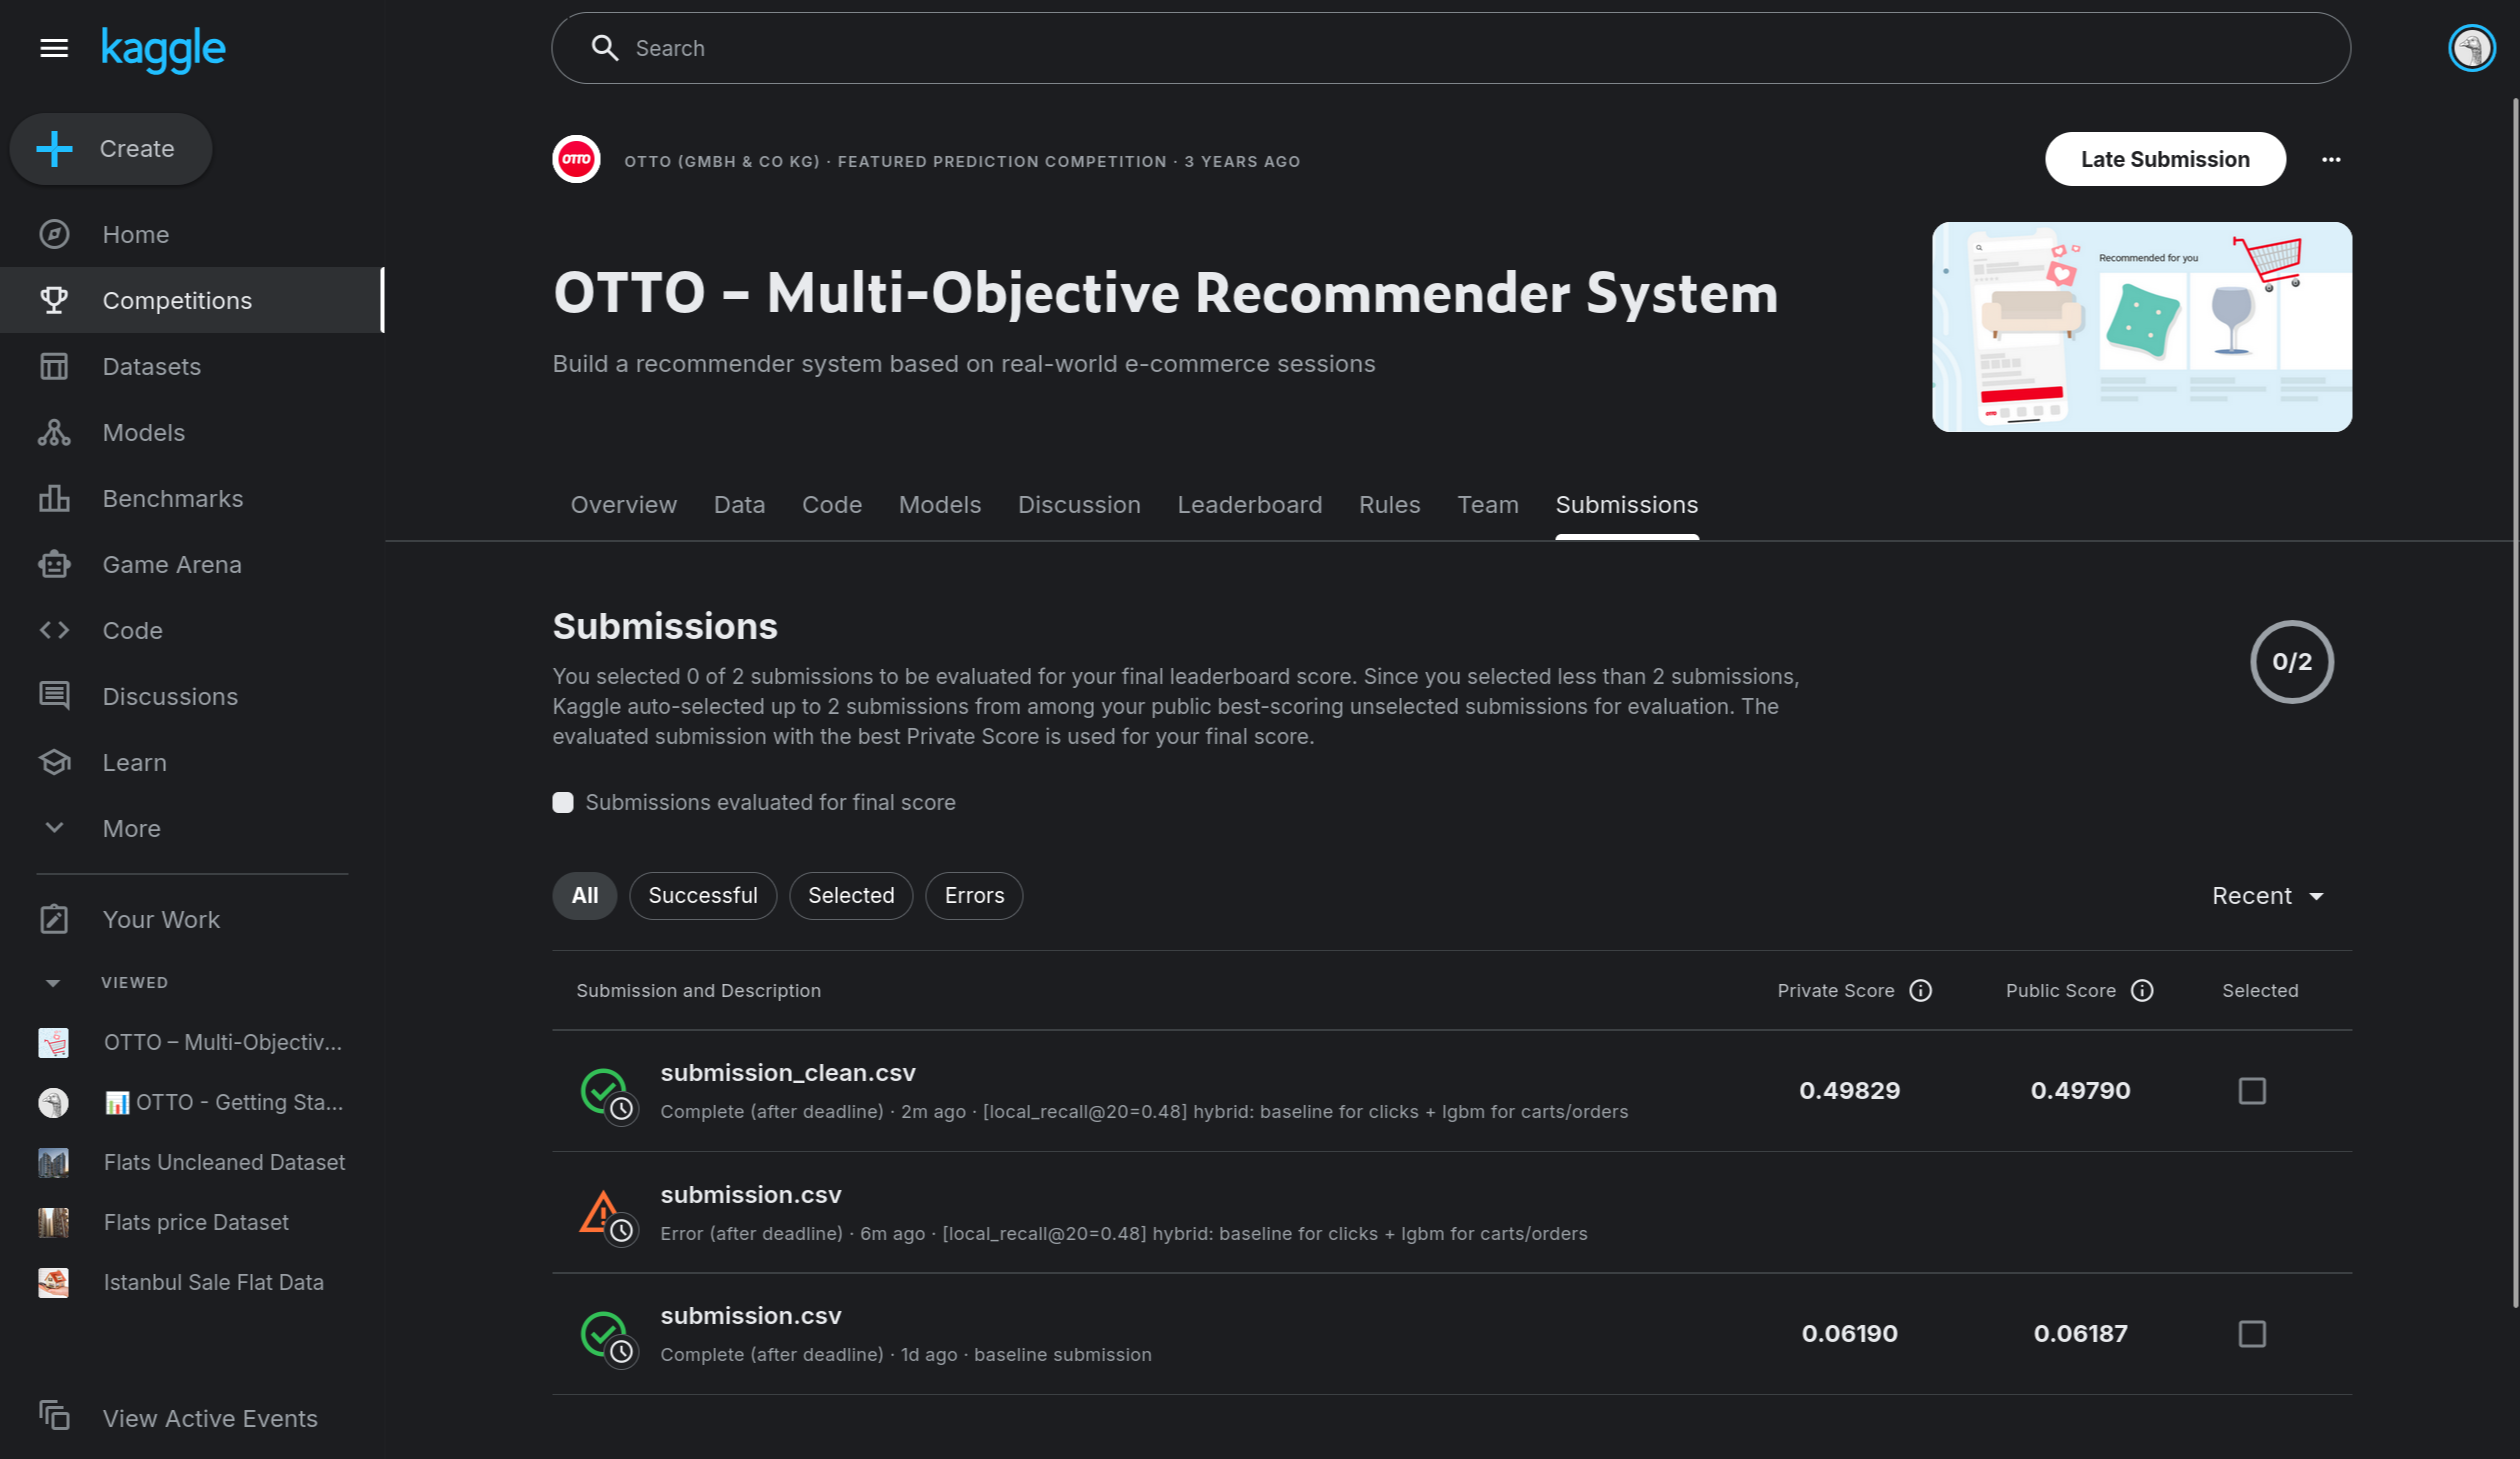